# 分析目標
闕又上老師於博音中提到一有趣說法：「景氣燈號很少失手」，本篇分析的目的即為以驗證此說法是否為真。

# 方法
以視覺化圖表，呈現台股指數與景氣燈號走勢。
由於數列尺度不同，數值以標準化與「除以初始值」處理，以觀察長期走勢。

# 結論
以五年為一區間、除以初始值的視覺效果較優，走勢不會過於陡峭、較容易觀察兩者關係。兩者趨勢較符合的區間為有四段：2000-2002, 2007-2009, 2018-2019, 2021-至今。
不過視覺化圖表仍具較多主觀成份，讀者可以自行判斷。

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from plotnine import (
    ggplot, aes, geom_col, geom_boxplot, geom_density, facet_wrap,
    labs, theme, element_text, scale_x_discrete
)
import plotnine as pn
from sklearn.preprocessing import MinMaxScaler, Normalizer, StandardScaler

In [2]:
taiwan_signal = pd.read_csv("景氣燈號_20260414 - Worksheet 2.csv")
taiwan_signal = taiwan_signal[taiwan_signal["date"] >= "2000-01"]
taiwan_signal["date"] = pd.to_datetime(taiwan_signal["date"])

In [6]:
SYMBOL = "^NDX"          # 台股加權指數
START  = "2000-01-01"
END    = "2026-03-01"

df = yf.download(SYMBOL, start=START, end=END, auto_adjust=False, progress=False, interval="1mo").reset_index()
df.columns = df.columns.get_level_values(0)

In [7]:
mix = pd.merge(taiwan_signal, df[["Date", "Close"]], how="left", left_on="date", right_on="Date")

In [8]:
mix[["signal_minmax", "Close_minmax"]] = MinMaxScaler().fit_transform(mix[["signal", "Close"]])
mix[["signal_z", "Close_z"]] = StandardScaler().fit_transform(mix[["signal", "Close"]])

In [9]:
mix["signal_pct"] = mix["signal"].pct_change()
mix["Close_pct"] = mix["Close"].pct_change()

In [22]:
mix['period'] = (mix['date'].dt.year // 5) * 5
mix['period_label'] = mix['period'].astype(str) + "-" + (mix['period'] + 4).astype(str)

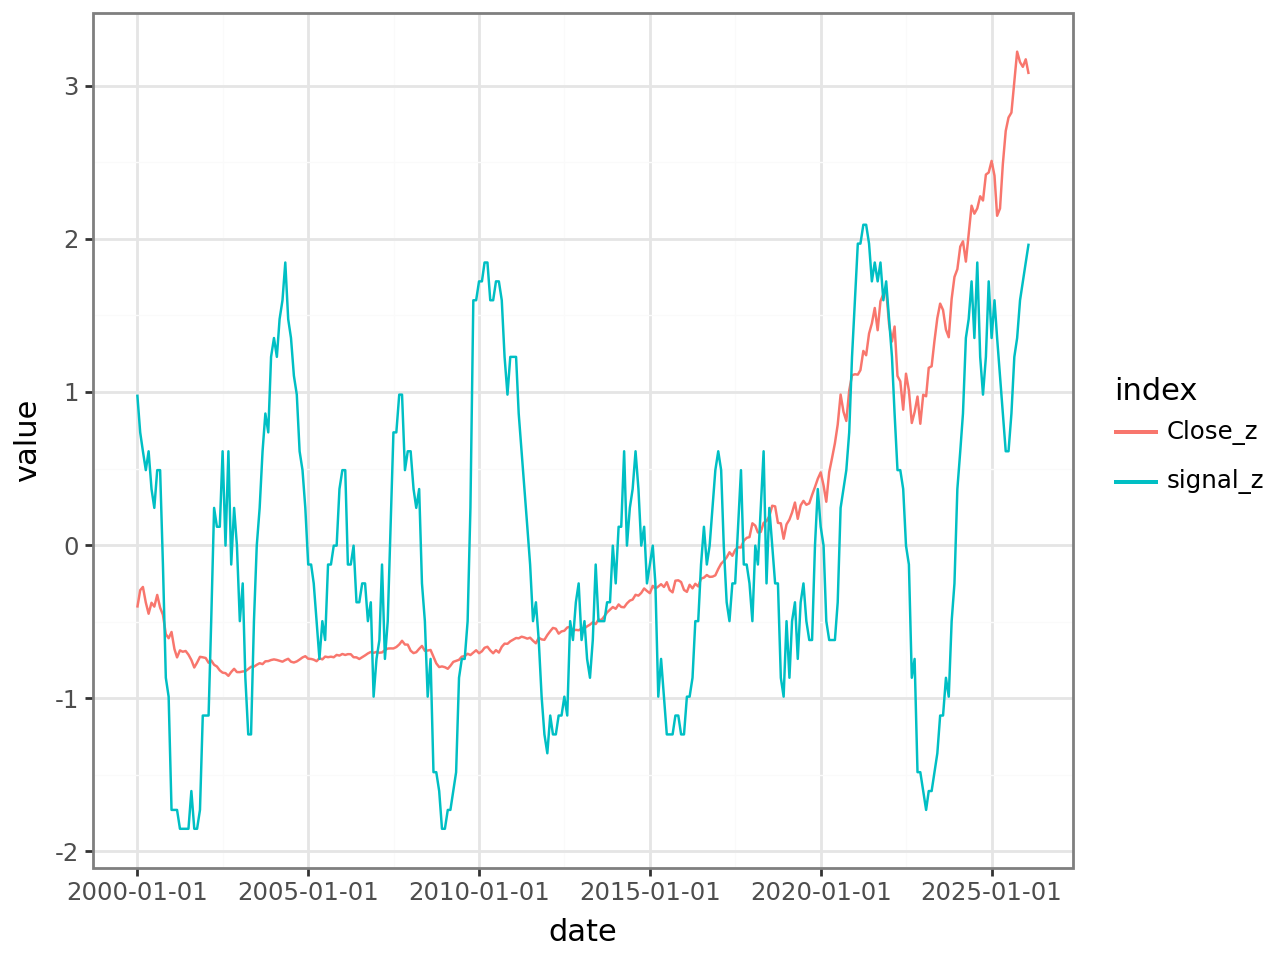

In [69]:
temp = mix[["date", "signal_z", "Close_z"]].melt(id_vars="date", value_vars=["signal_z", "Close_z"], var_name="index")
(
    ggplot(temp, aes(x="date", y="value", color="index"))
    + pn.geom_line()
    + pn.theme_bw()
)

### 標準化

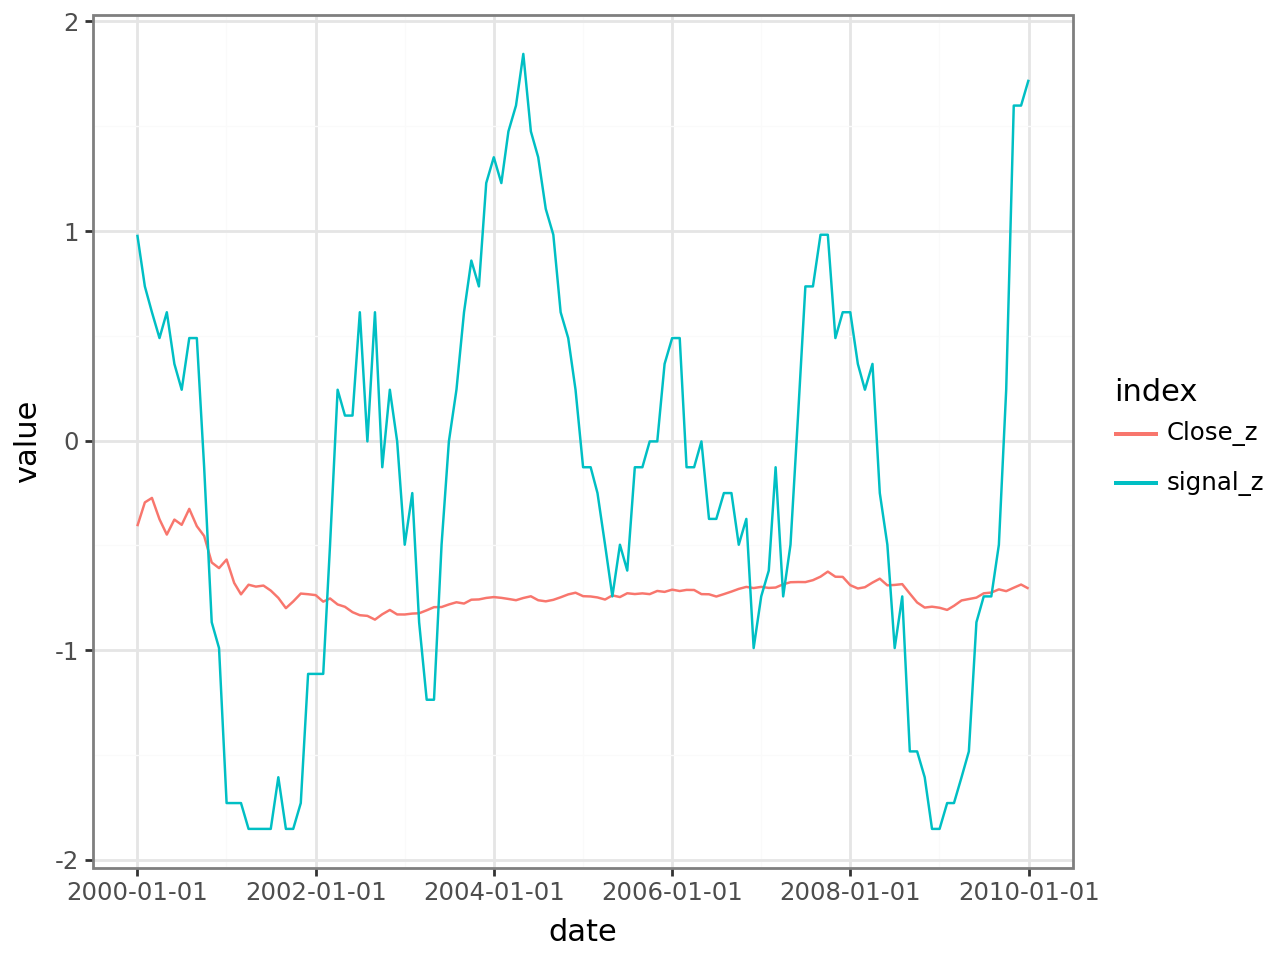

In [93]:
temp = (
    mix[mix["date"].between("2000-01", "2010-01")]
    [["date", "signal_z", "Close_z"]]
    .melt(id_vars="date", value_vars=["signal_z", "Close_z"], var_name="index")#.set_index("date")
       )
(
    ggplot(temp, aes(x="date", y="value", color="index"))
    + pn.geom_line()
    + pn.theme_bw()
)

### 選擇特定區間

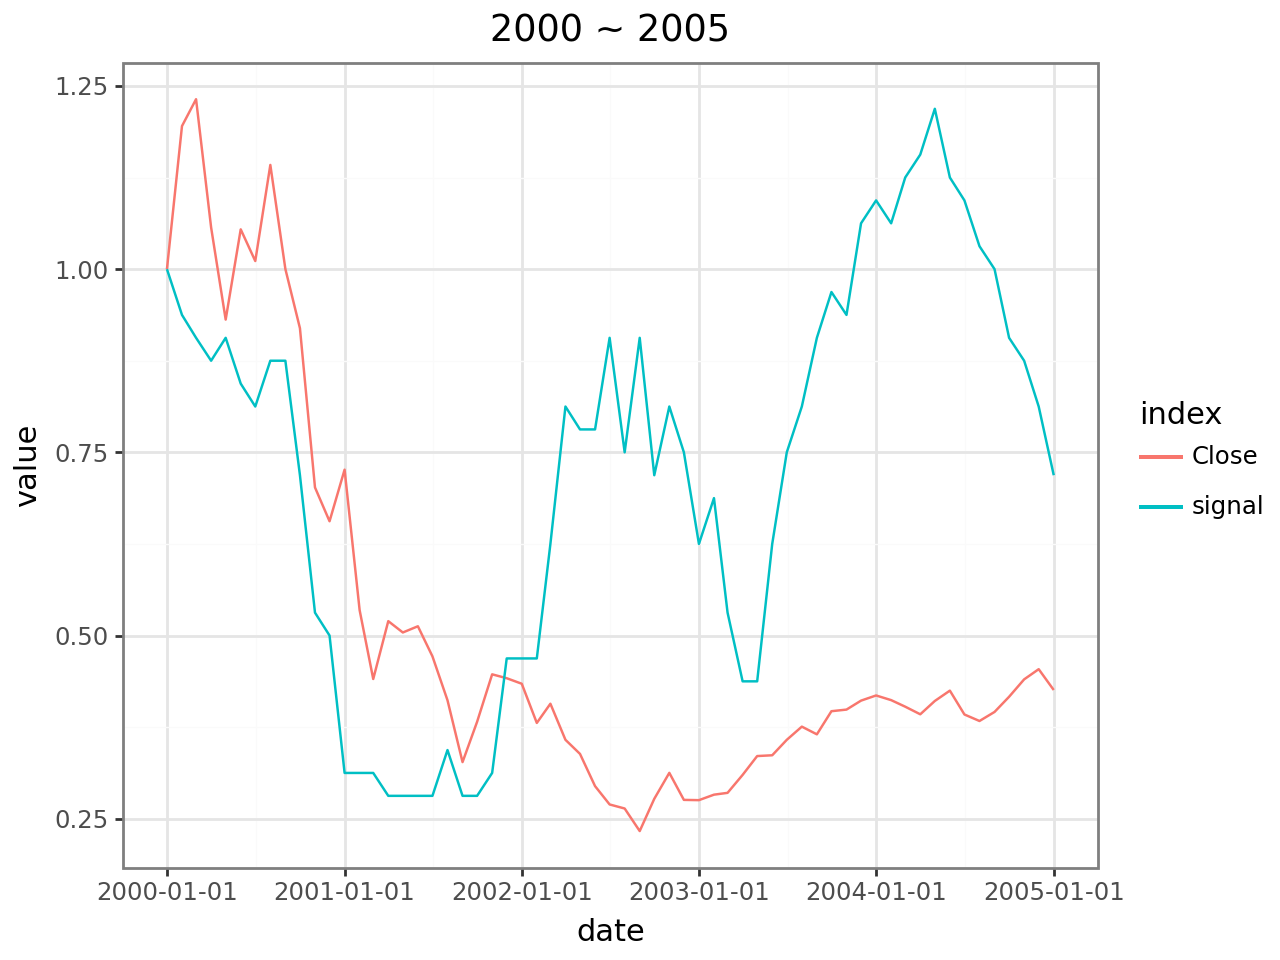

In [19]:
start = "2000-01"
end = "2005-01"
temp = (
    mix[mix["date"].between(start, end)]
    .copy()
)
# temp = mix[["date", "signal", "Close"]]
temp["signal"] = temp["signal"] / temp["signal"].values[0]
temp["Close"] = temp["Close"] / temp["Close"].values[0]
temp = temp.melt(id_vars="date", value_vars=["signal", "Close"], var_name="index")#.set_index("date")
       

(
    ggplot(temp, aes(x="date", y="value", color="index"))
    + pn.geom_line()
    + pn.theme_bw()
    + pn.ggtitle(f"{start[:4]} ~ {end[:4]}")
)

### 每五年為一區間 (除以初始值)

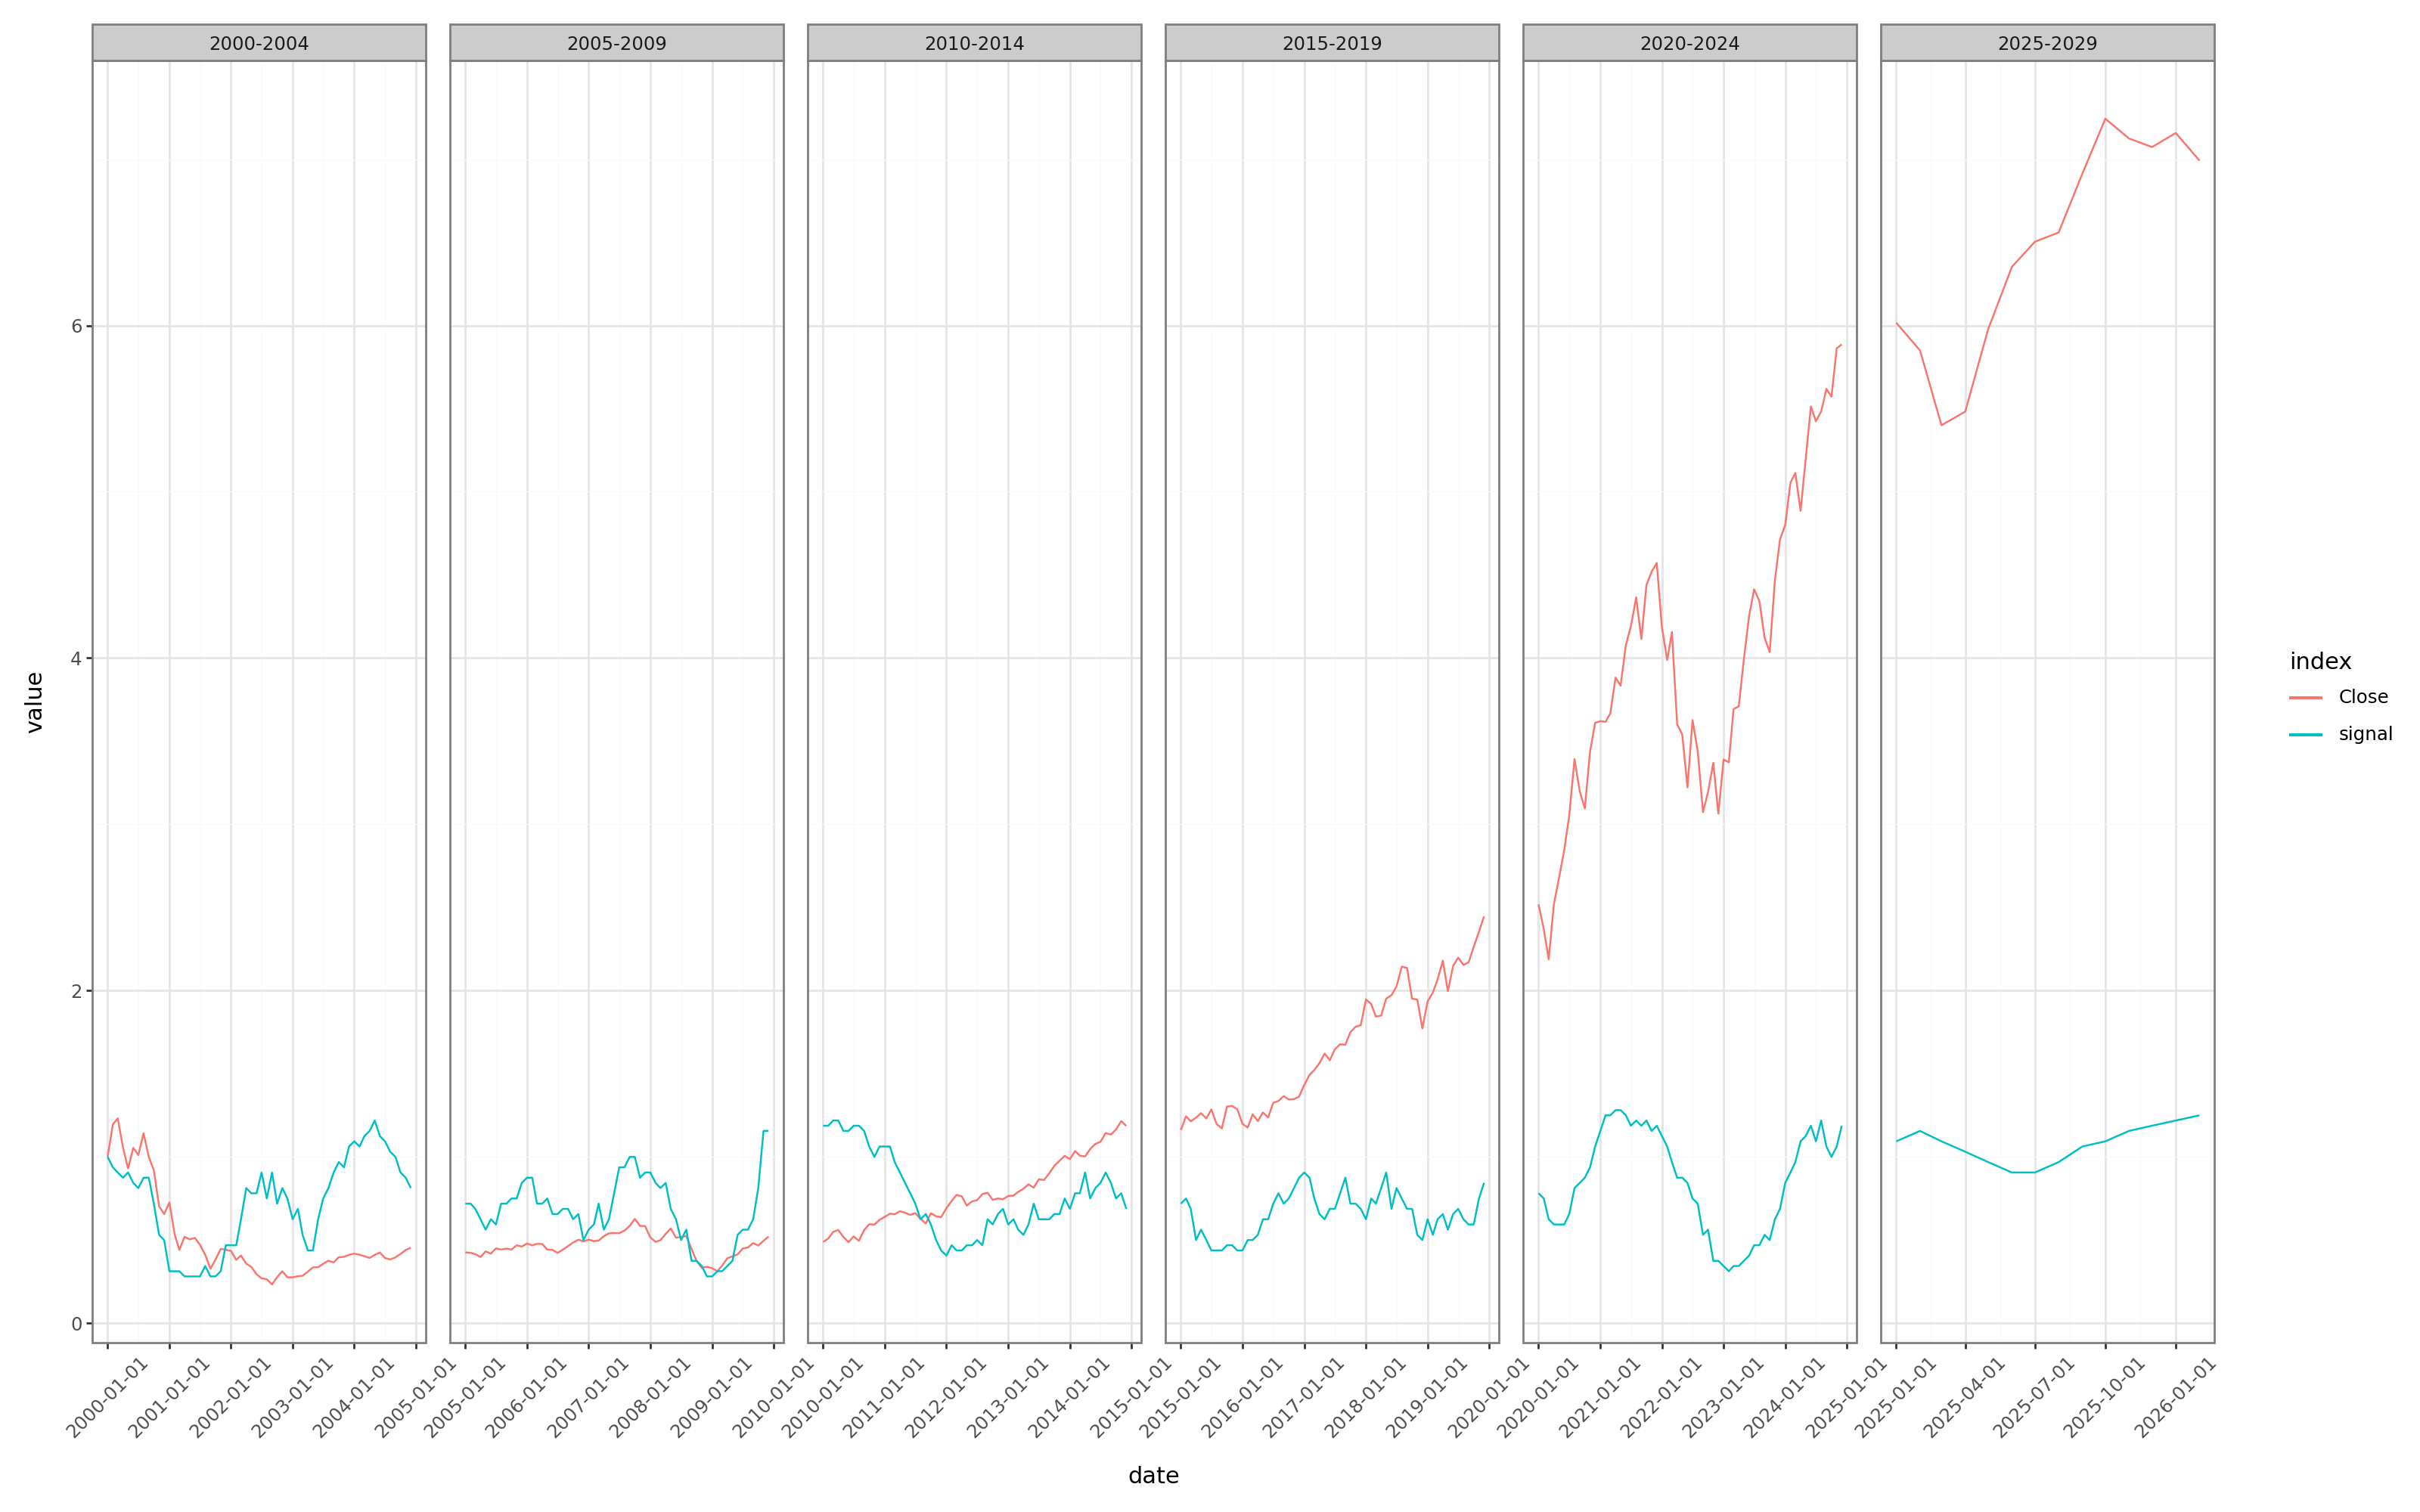

In [32]:
temp = (
    mix
    .copy()
)
temp["signal"] = temp["signal"] / temp["signal"].values[0]
temp["Close"] = temp["Close"] / temp["Close"].values[0]
temp = temp.melt(id_vars="date", value_vars=["signal", "Close"], var_name="index")#.set_index("date")
temp['period'] = (temp['date'].dt.year // 5) * 5
temp['period_label'] = temp['period'].astype(str) + "-" + (temp['period'] + 4).astype(str)

(
    ggplot(temp, aes(x="date", y="value", color="index"))
    + pn.geom_line()
    + pn.theme_bw()
    + pn.facet_wrap("~period_label", nrow=1, scales="free_x")
    + pn.theme(figure_size=(16,10), axis_text_x=pn.element_text(rotation=45))
)

### 每五年為一區間 (標準化)

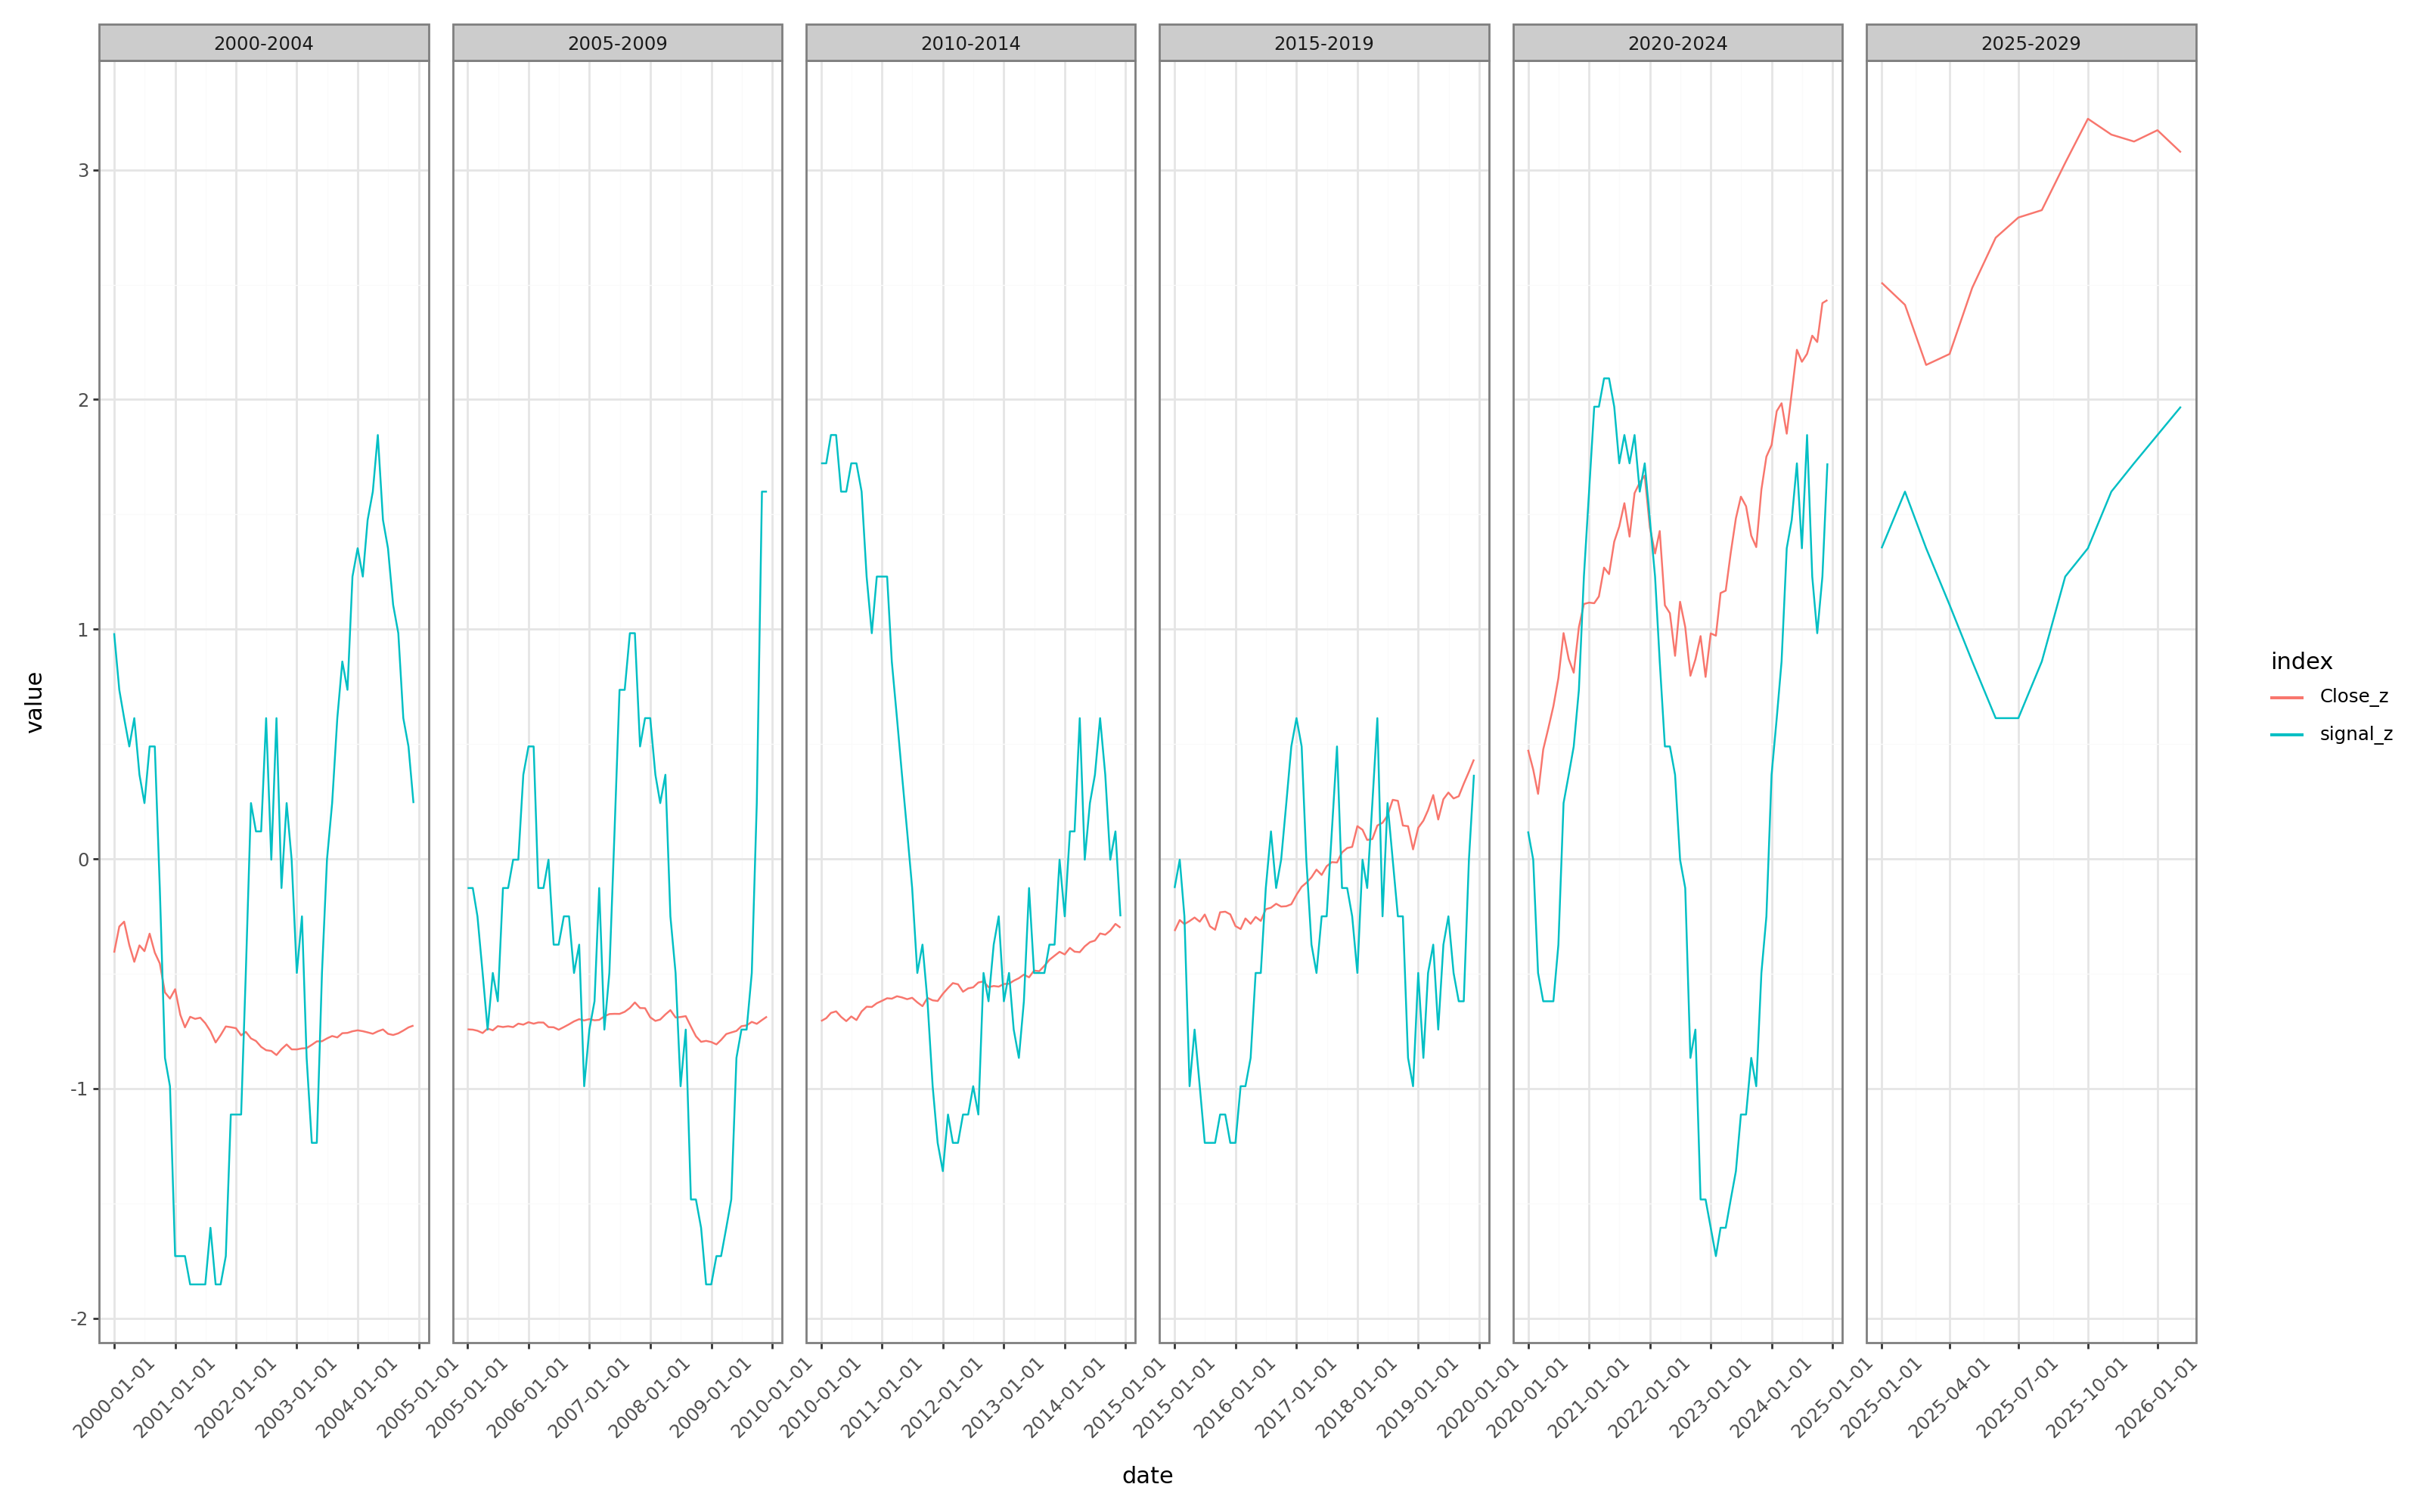

In [33]:
temp = (
    mix
    .copy()
)
# temp["signal"] = temp["signal_z"] / temp["signal"].values[0]
# temp["Close"] = temp["Close"] / temp["Close"].values[0]
temp = temp.melt(id_vars="date", value_vars=["signal_z", "Close_z"], var_name="index")#.set_index("date")
temp['period'] = (temp['date'].dt.year // 5) * 5
temp['period_label'] = temp['period'].astype(str) + "-" + (temp['period'] + 4).astype(str)

(
    ggplot(temp, aes(x="date", y="value", color="index"))
    + pn.geom_line()
    + pn.theme_bw()
    + pn.facet_wrap("~period_label", nrow=1, scales="free_x")
    + pn.theme(figure_size=(16,10), axis_text_x=pn.element_text(rotation=45))
)

## Appendix

In [ ]:
## 歷史走勢（百分比變化）
temp = mix[["date", "signal_pct", "Close_pct"]].melt(id_vars="date", value_vars=["signal_pct", "Close_pct"], var_name="index")
(
    ggplot(temp, aes(x="date", y="value", color="index"))
    + pn.geom_line()
    + pn.theme_bw()
    + pn.facet_wrap("~index", dir="h")
)

In [ ]:
## MinMax
temp = (
    mix
    [["date", "signal_minmax", "Close_minmax"]]
    .melt(id_vars="date", value_vars=["signal_minmax", "Close_minmax"], var_name="index")#.set_index("date")
       )
(
    ggplot(temp, aes(x="date", y="value", color="index"))
    + pn.geom_line()
    + pn.theme_bw()
)